In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

In [5]:
# Load the dataset
df = pd.read_csv('fifa21 raw data v2.csv')

<ipython-input-5-26d981ff4712>:2: DtypeWarning: Columns (76) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('fifa21 raw data v2.csv')


In [6]:
# Check the first few rows (4 by default)
print(df.head())

       ID               Name                      LongName  \
0  158023           L. Messi                  Lionel Messi   
1   20801  Cristiano Ronaldo  C. Ronaldo dos Santos Aveiro   
2  200389           J. Oblak                     Jan Oblak   
3  192985       K. De Bruyne               Kevin De Bruyne   
4  190871          Neymar Jr    Neymar da Silva Santos Jr.   

                                           photoUrl  \
0  https://cdn.sofifa.com/players/158/023/21_60.png   
1  https://cdn.sofifa.com/players/020/801/21_60.png   
2  https://cdn.sofifa.com/players/200/389/21_60.png   
3  https://cdn.sofifa.com/players/192/985/21_60.png   
4  https://cdn.sofifa.com/players/190/871/21_60.png   

                                           playerUrl Nationality  Age  ↓OVA  \
0  http://sofifa.com/player/158023/lionel-messi/2...   Argentina   33    93   
1  http://sofifa.com/player/20801/c-ronaldo-dos-s...    Portugal   35    92   
2  http://sofifa.com/player/200389/jan-oblak/210006/    Slo

In [7]:
# Get information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                18979 non-null  int64 
 1   Name              18979 non-null  object
 2   LongName          18979 non-null  object
 3   photoUrl          18979 non-null  object
 4   playerUrl         18979 non-null  object
 5   Nationality       18979 non-null  object
 6   Age               18979 non-null  int64 
 7   ↓OVA              18979 non-null  int64 
 8   POT               18979 non-null  int64 
 9   Club              18979 non-null  object
 10  Contract          18979 non-null  object
 11  Positions         18979 non-null  object
 12  Height            18979 non-null  object
 13  Weight            18979 non-null  object
 14  Preferred Foot    18979 non-null  object
 15  BOV               18979 non-null  int64 
 16  Best Position     18979 non-null  object
 17  Joined      

In [8]:
# Check for missing values
print(df.isnull().sum())

ID              0
Name            0
LongName        0
photoUrl        0
playerUrl       0
             ... 
PAS             0
DRI             0
DEF             0
PHY             0
Hits         2595
Length: 77, dtype: int64


**1. Converting Height and Weight to Numerical Forms**

In [9]:
# Convert height from string (e.g., "185cm") to numerical (185)
def convert_height(height_str):
    if isinstance(height_str, str):
        if "cm" in height_str:
            return int(height_str.replace('cm', ''))
        elif "'" in height_str:  # For heights in feet and inches (e.g., 6'2")
            feet, inches = height_str.split("'")
            inches = inches.replace('"', '')
            return int(feet) * 30.48 + int(inches) * 2.54  # Convert to cm
    return height_str

# Convert weight from string (e.g., "75kg") to numerical (75)
def convert_weight(weight_str):
    if isinstance(weight_str, str):
        if "kg" in weight_str:
            return int(weight_str.replace('kg', ''))
        elif "lbs" in weight_str:  # For weights in pounds
            return int(weight_str.replace('lbs', '')) * 0.453592  # Convert to kg
    return weight_str

# Apply the conversion functions
df['Height_cm'] = df['Height'].apply(convert_height)
df['Weight_kg'] = df['Weight'].apply(convert_weight)


**2. Removing Newline Characters from All Columns**

In [10]:
# Remove newline characters from all string columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.replace('\n', '') if df[col].dtype == 'object' else df[col]


**3. Checking Players at a Club for More Than 10 Years**

In [11]:
# Convert 'Joined' column to datetime
df['Joined'] = pd.to_datetime(df['Joined'], errors='coerce')

# Calculate years at the club (as of 2021, since the dataset is FIFA 21)
current_date = pd.to_datetime('2021-05-01')
df['Years_at_Club'] = (current_date - df['Joined']).dt.days / 365.25

# Find players who have been at their club for more than 10 years
long_serving_players = df[df['Years_at_Club'] > 10][['Name', 'Club', 'Joined', 'Years_at_Club']]
print("Players at their club for more than 10 years:")
print(long_serving_players)


Players at their club for more than 10 years:
                   Name               Club     Joined  Years_at_Club
0              L. Messi       FC Barcelona 2004-07-01      16.832307
15           K. Benzema        Real Madrid 2009-07-09      11.811088
16         Sergio Ramos        Real Madrid 2005-08-01      15.748118
23              H. Kane  Tottenham Hotspur 2010-07-01      10.833676
39         G. Chiellini           Juventus 2005-07-01      15.832991
...                 ...                ...        ...            ...
16109          K. Miura        Yokohama FC 2005-07-01      15.832991
16519       J. Popelard    FC Chambly Oise 2010-07-01      10.833676
16709       M. Al Wakid           Al Hilal 2009-10-01      11.581109
17073  K. Stamatopoulos                AIK 2011-01-01      10.329911
17186        Yao Hanlin         Wuhan Zall 2010-01-01      11.329227

[243 rows x 4 columns]


**4. Converting Value, Wage, and Release Clause to Numbers**

In [12]:
# Function to convert currency strings to numeric values
def convert_currency(value):
    if isinstance(value, str):
        value = value.replace('€', '')
        if 'M' in value:
            return float(value.replace('M', '')) * 1000000
        elif 'K' in value:
            return float(value.replace('K', '')) * 1000
        else:
            return float(value)
    return value

# Apply the conversion to Value, Wage, and Release Clause columns
df['Value_numeric'] = df['Value'].apply(convert_currency)
df['Wage_numeric'] = df['Wage'].apply(convert_currency)
df['Release_Clause_numeric'] = df['Release Clause'].apply(convert_currency)


**5. Removing Star Characters and Making Columns Numerical**

In [13]:
# Function to remove star characters and convert to numeric
def remove_stars(value):
    if isinstance(value, str):
        # Remove star symbols and convert to numeric
        return float(re.sub(r'[★\s]', '', value))
    return value

# Identify columns with star characters
star_columns = ['Skill Moves', 'Weak Foot', 'International Reputation']

# Apply the function to these columns
for col in star_columns:
    if col in df.columns:
        df[col + '_numeric'] = df[col].apply(remove_stars)


**Saving as a new file**

In [27]:
import pandas as pd
import numpy as np
import re

# Load data
df = pd.read_csv('fifa21 raw data v2.csv', low_memory=False)

# 1. Remove newline characters from all string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.replace('\n', '', regex=False)

# 2. Height and Weight to numeric (replace original columns)
def height_to_cm(x):
    if isinstance(x, str):
        x = x.strip()
        if x.endswith('cm'):
            return int(x.replace('cm', ''))
        elif "'" in x:
            parts = x.replace('"', '').split("'")
            try:
                return int(parts[0]) * 30.48 + int(parts[1]) * 2.54
            except:
                return np.nan
    return np.nan

def weight_to_kg(x):
    if isinstance(x, str):
        x = x.strip()
        if x.endswith('kg'):
            return int(x.replace('kg', ''))
        elif x.endswith('lbs'):
            return round(int(x.replace('lbs', '')) * 0.453592, 1)
    return np.nan

df['Height'] = df['Height'].apply(height_to_cm)
df['Weight'] = df['Weight'].apply(weight_to_kg)

# 3. 'Joined' to datetime and years at club (replace 'Joined' with years)
df['Joined'] = pd.to_datetime(df['Joined'], errors='coerce')
current_date = pd.to_datetime('2021-05-01')
df['Joined'] = ((current_date - df['Joined']).dt.days / 365.25).round(2)

# 4. Value, Wage, Release Clause to numbers (replace original columns)
def value_to_numeric(x):
    if pd.isnull(x):
        return np.nan
    x = str(x).replace('€', '').replace(',', '').strip()
    if x.endswith('M'):
        return float(x[:-1]) * 1_000_000
    elif x.endswith('K'):
        return float(x[:-1]) * 1_000
    try:
        return float(x)
    except:
        return np.nan

for col in ['Value', 'Wage', 'Release Clause']:
    if col in df.columns:
        df[col] = df[col].apply(value_to_numeric)

# 5. Remove star characters and make columns numeric (replace original columns)
star_cols = [col for col in df.columns if df[col].astype(str).str.contains('★').any()]
def strip_star(x):
    if isinstance(x, str):
        return re.sub(r'[★\s]', '', x)
    return x

for col in star_cols:
    df[col] = df[col].apply(strip_star).replace('', np.nan).astype(float)

# Save the cleaned DataFrame, overwriting the original columns
df.to_csv('fifa21-cleaned-replaced.csv', index=False)


**6. Identifying Highly Valuable but Underpaid Players**

Highly valuable but underpaid players:
                 Name                    Club  Value_numeric  Wage_numeric
346           Ismaily        Shakhtar Donetsk     22000000.0        1000.0
354            Marlos        Shakhtar Donetsk     20500000.0        2000.0
358            Taison        Shakhtar Donetsk     20500000.0        2000.0
372      D. Livaković           Dinamo Zagreb     24500000.0         900.0
373      V. Tsygankov             Dynamo Kyiv     34000000.0        1000.0
...               ...                     ...            ...           ...
3299         Léo Jabá                    PAOK      5500000.0         750.0
3300   Marcos Antonio        Shakhtar Donetsk      5500000.0         550.0
3407     S. Rodríguez  Nacional de Montevideo      5500000.0         700.0
3430             Dodô        Shakhtar Donetsk      5500000.0         500.0
3475  G. Tsitaishvili             Dynamo Kyiv      5500000.0         500.0

[61 rows x 4 columns]


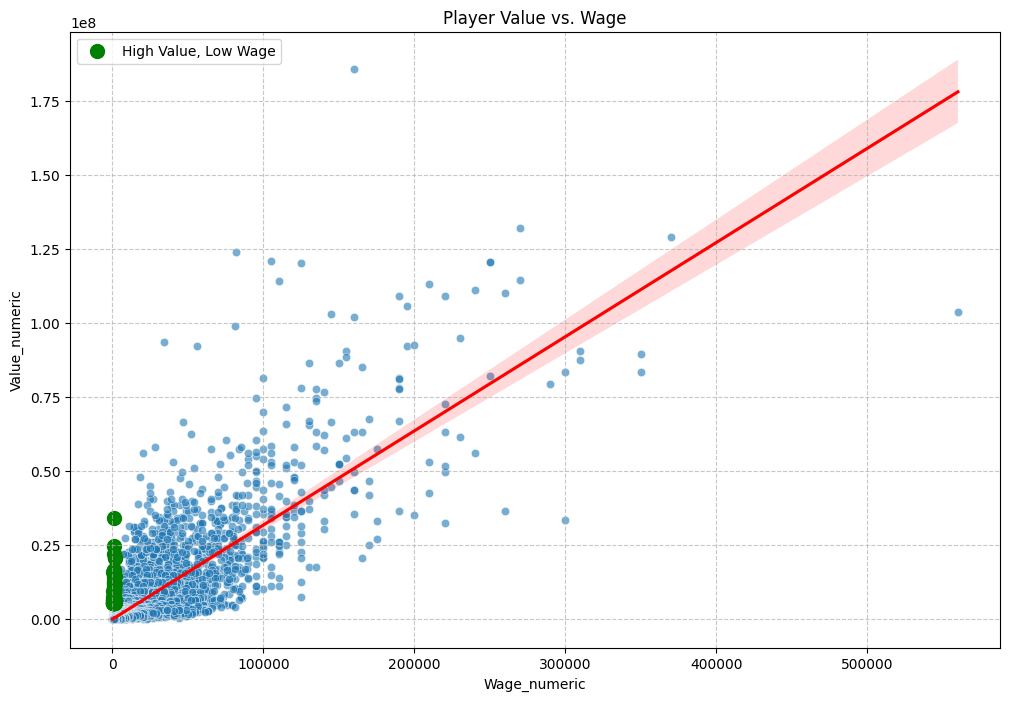

In [14]:
# Create a scatter plot to visualize the relationship between value and wage
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Wage_numeric', y='Value_numeric', data=df, alpha=0.6)
plt.title('Player Value vs. Wage')
plt.xlabel('Wage (€)')
plt.ylabel('Value (€)')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a trend line
sns.regplot(x='Wage_numeric', y='Value_numeric', data=df, scatter=False, color='red')

# Identify players with high value but low wage
# We can define this as players whose value is in the top 10% but wage is below the median
high_value_threshold = df['Value_numeric'].quantile(0.9)
median_wage = df['Wage_numeric'].median()

high_value_low_wage_players = df[(df['Value_numeric'] >= high_value_threshold) &
                                 (df['Wage_numeric'] < median_wage)]

print("Highly valuable but underpaid players:")
print(high_value_low_wage_players[['Name', 'Club', 'Value_numeric', 'Wage_numeric']])

# Highlight these players on the plot
plt.scatter(high_value_low_wage_players['Wage_numeric'],
            high_value_low_wage_players['Value_numeric'],
            color='green', s=100, label='High Value, Low Wage')
plt.legend()
plt.show()


**7. Age Distribution of Players**

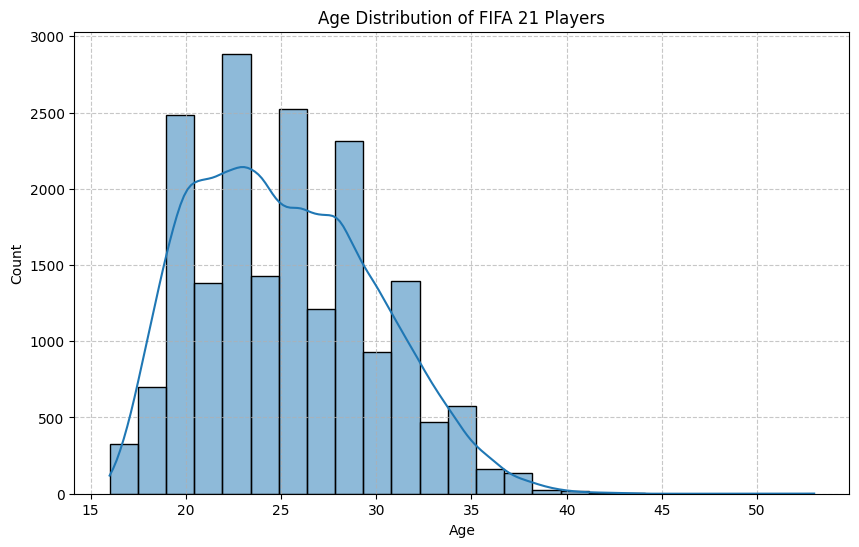

In [16]:
# Create a histogram of player ages
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=25, kde=True)
plt.title('Age Distribution of FIFA 21 Players')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


**9. Nationality Distribution**

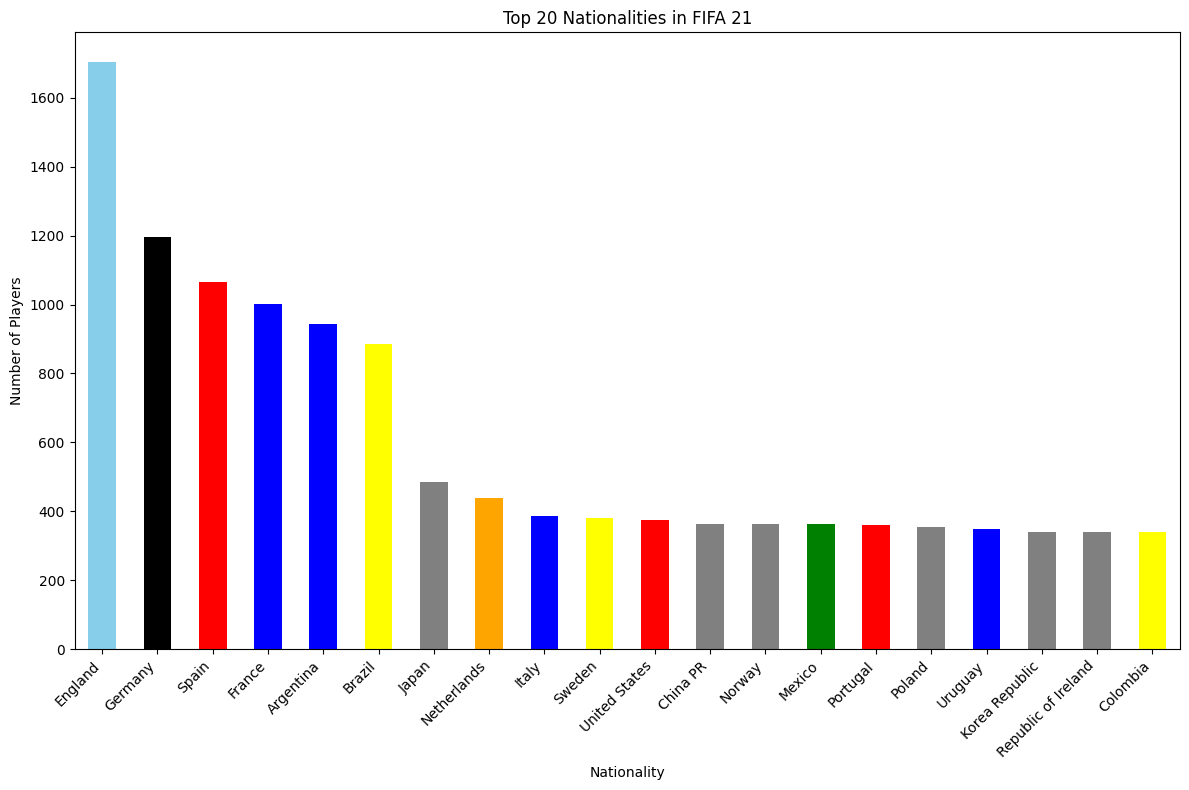

In [21]:
jersey_colors = {
    'England': 'skyblue',
    'Germany': 'black',
    'Spain': 'red',
    'Argentina': 'blue',
    'Brazil': 'yellow',
    'France': 'blue',
    'Italy': 'blue',
    'Portugal': 'red',
    'Netherlands': 'orange',
    'Belgium': 'red',
    'Mexico': 'green',
    'United States': 'red',
    'Colombia': 'yellow',
    'Uruguay': 'blue',
    'Switzerland': 'red',
    'Chile': 'red',
    'Sweden': 'yellow',
    'Senegal': 'green',
    'Wales': 'red',
    'Denmark': 'red'
    # Add more countries and colors as needed
}

# Count the number of players by nationality (top 20)
nationality_counts = df['Nationality'].value_counts().head(20)

# Create a bar chart with custom colors
plt.figure(figsize=(12, 8))

# Get colors for each nationality from the dictionary
colors = [jersey_colors.get(nationality, 'gray') for nationality in nationality_counts.index]

nationality_counts.plot(kind='bar', color=colors)  # Apply custom colors

plt.title('Top 20 Nationalities in FIFA 21')
plt.xlabel('Nationality')
plt.ylabel('Number of Players')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Correlation Heatmap of Key Attributes**

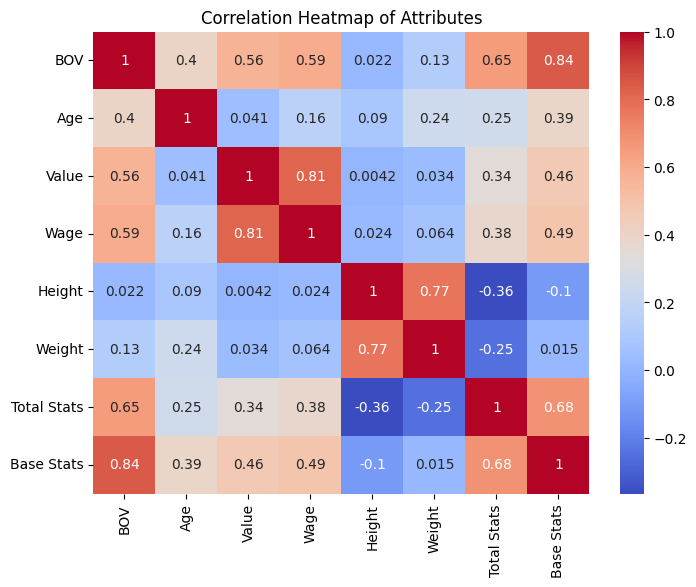

In [35]:
attributes = ['BOV', 'Age', 'Value', 'Wage', 'Height', 'Weight', 'Total Stats', 'Base Stats']
corr = df[attributes].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Attributes')
plt.show()


**Distribution of Player Heights and Weights**

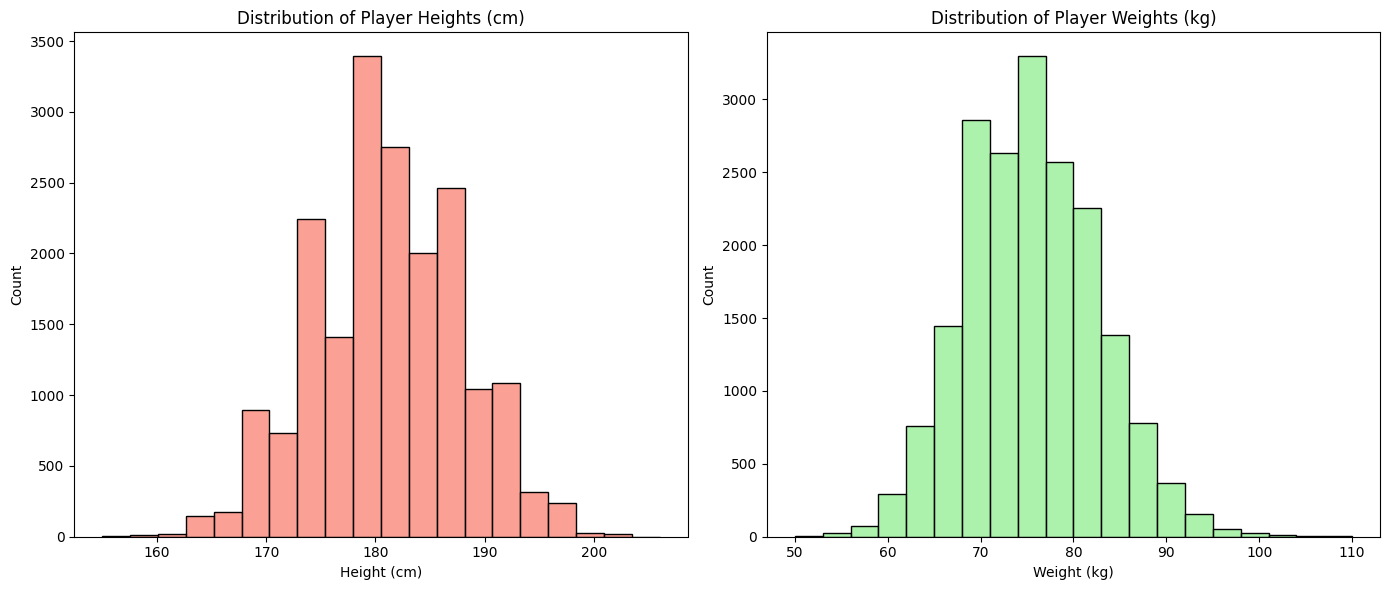

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.histplot(df['Height'], bins=20, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Player Heights (cm)')
axes[0].set_xlabel('Height (cm)')

sns.histplot(df['Weight'], bins=20, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Player Weights (kg)')
axes[1].set_xlabel('Weight (kg)')
plt.tight_layout()
plt.show()


**Potential vs. Overall: Room for Growth**

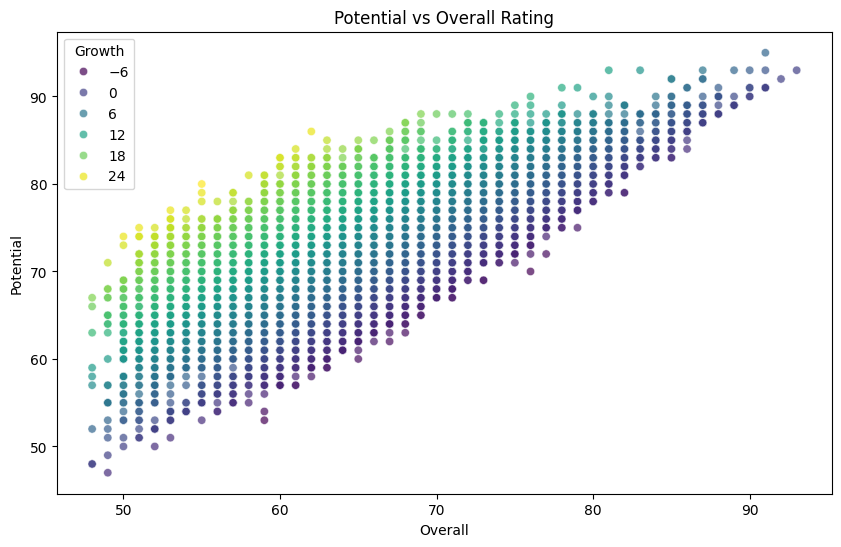

In [41]:
df['Growth'] = df['POT'] - df['BOV']
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['BOV'], y=df['POT'], hue=df['Growth'], palette='viridis', alpha=0.7)
plt.title('Potential vs Overall Rating')
plt.xlabel('Overall')
plt.ylabel('Potential')
plt.show()


**Wage Distribution by League or Club**

<ipython-input-42-b9c2f82de11d>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=club_wages.values, y=club_wages.index, palette='rocket')


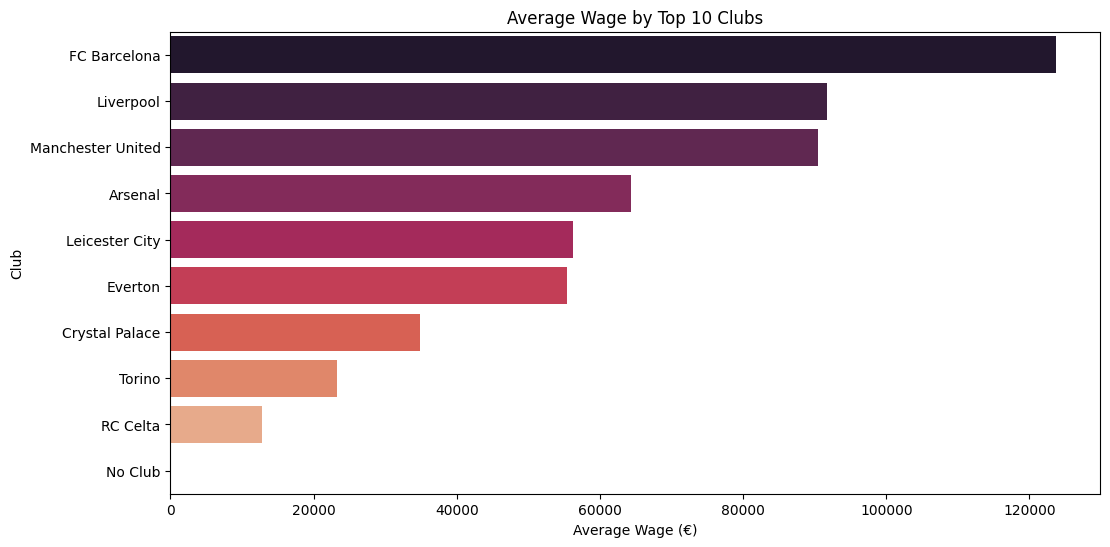

In [42]:
top_clubs = df['Club'].value_counts().head(10).index
club_wages = df[df['Club'].isin(top_clubs)].groupby('Club')['Wage'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=club_wages.values, y=club_wages.index, palette='rocket')
plt.title('Average Wage by Top 10 Clubs')
plt.xlabel('Average Wage (€)')
plt.ylabel('Club')
plt.show()


**Players with Over 10 Years at the Same Club**

In [43]:
veterans = df[df['Joined'] > 10]  # 'Joined' column now represents years at club
print(veterans[['Name', 'Club', 'Joined']])


                   Name               Club  Joined
0              L. Messi       FC Barcelona   16.83
15           K. Benzema        Real Madrid   11.81
16         Sergio Ramos        Real Madrid   15.75
23              H. Kane  Tottenham Hotspur   10.83
39         G. Chiellini           Juventus   15.83
...                 ...                ...     ...
16109          K. Miura        Yokohama FC   15.83
16519       J. Popelard    FC Chambly Oise   10.83
16709       M. Al Wakid           Al Hilal   11.58
17073  K. Stamatopoulos                AIK   10.33
17186        Yao Hanlin         Wuhan Zall   11.33

[243 rows x 3 columns]


**Age vs. Value: Are Older Players Less Valuable?**

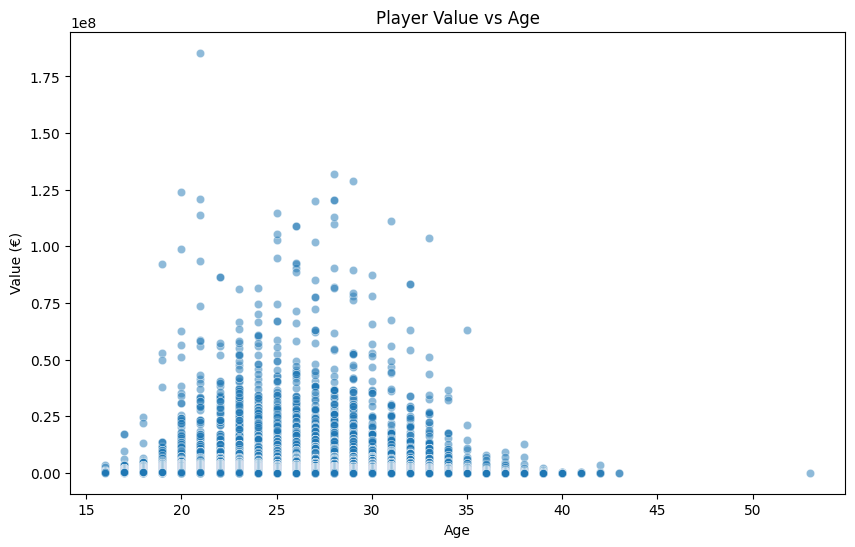

In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Age'], y=df['Value'], alpha=0.5)
plt.title('Player Value vs Age')
plt.xlabel('Age')
plt.ylabel('Value (€)')
plt.show()


**Clubs with the Most Players of High Potential**

Top 10 clubs with most high potential players:
Club
Tottenham Hotspur      28
Real Madrid            28
Liverpool              28
Manchester United      27
Manchester City        27
Paris Saint-Germain    25
Chelsea                25
Arsenal                25
Atlético Madrid        23
FC Barcelona           23
Name: count, dtype: int64


<ipython-input-47-af9d97f16936>:4: DtypeWarning: Columns (76) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('fifa21-cleaned-replaced.csv')


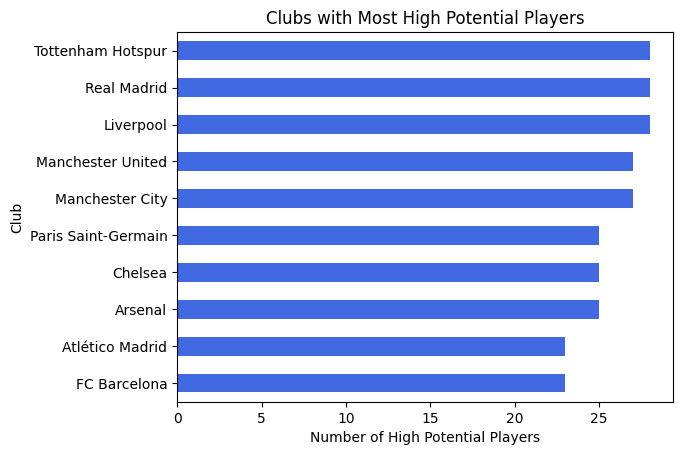

In [47]:
import pandas as pd

# Load data
df = pd.read_csv('fifa21-cleaned-replaced.csv')

# Define high potential threshold (Here we have taken 80)
high_potential = df[df['POT'] >= 80]

# Count high potential players per club
club_counts = high_potential['Club'].value_counts().head(10)
print("Top 10 clubs with most high potential players:")
print(club_counts)

import matplotlib.pyplot as plt
club_counts.plot(kind='barh', color='royalblue')
plt.xlabel('Number of High Potential Players')
plt.title('Clubs with Most High Potential Players')
plt.gca().invert_yaxis()
plt.show()


**Effect of Skill Moves and Weak Foot on Value and Wage**

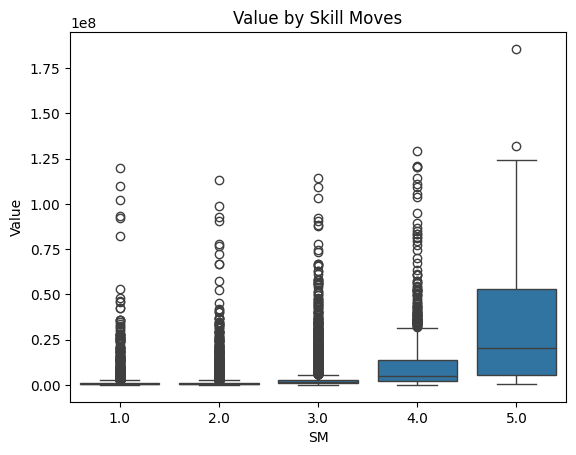

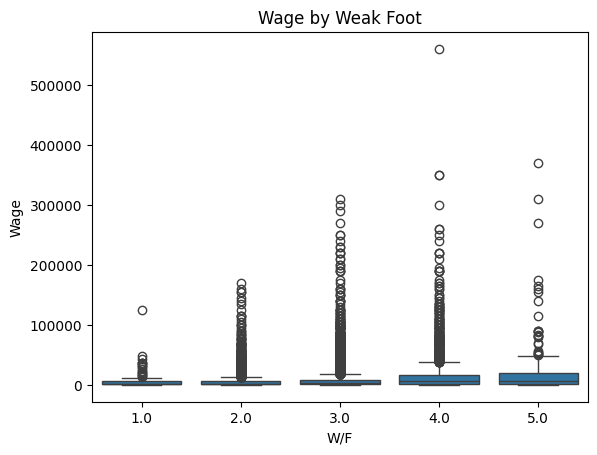

In [54]:
# Remove missing values
df_sw = df.dropna(subset=['SM', 'W/F', 'Value', 'Wage'])

# Skill Moves vs Value
sns.boxplot(x='SM', y='Value', data=df_sw)
plt.title('Value by Skill Moves')
plt.show()

# Weak Foot vs Wage
sns.boxplot(x='W/F', y='Wage', data=df_sw)
plt.title('Wage by Weak Foot')
plt.show()


**Distribution of Preferred Foot Among Top Players**

Preferred foot distribution among top players:
Preferred Foot
Right    487
Left     165
Name: count, dtype: int64


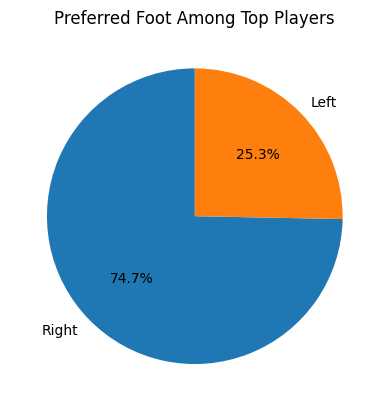

In [55]:
top_players = df[df['BOV'] >= 80]
foot_counts = top_players['Preferred Foot'].value_counts()
print("Preferred foot distribution among top players:")
print(foot_counts)

# Pie chart
foot_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Preferred Foot Among Top Players')
plt.ylabel('')
plt.show()


**Physical Attribute Trends by Position**

                   Height     Weight
Best Position                       
GK             188.380704  81.737253
CB             186.041286  79.283614
ST             182.842799  77.101604
CDM            180.158408  74.380761
CM             179.221891  73.003152
LB             178.389705  72.447422
RB             178.113939  72.205283
LWB            177.700690  71.406130
RWB            177.444043  71.790614
CF             177.015128  73.067949


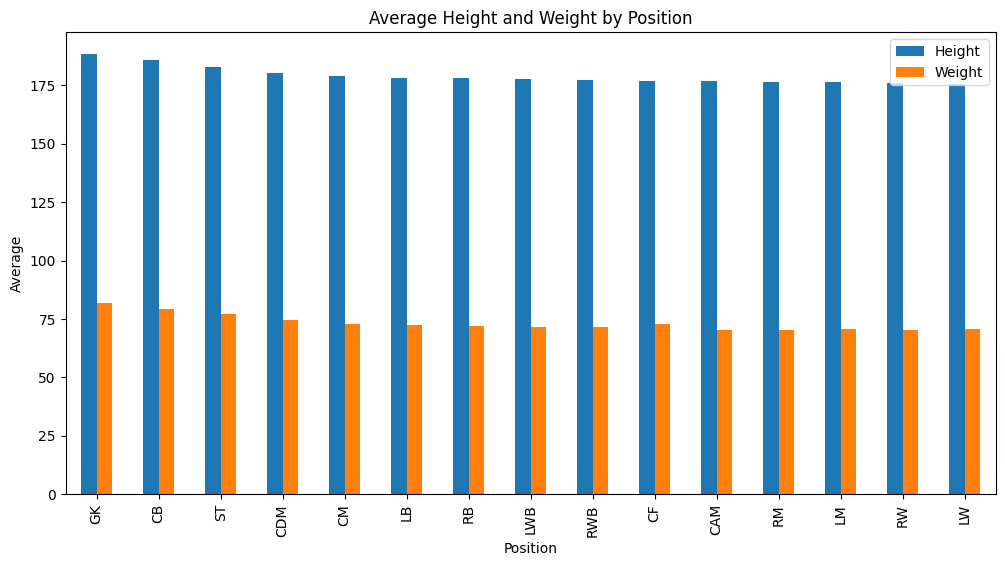

In [57]:
phys_by_pos = df.groupby('Best Position')[['Height', 'Weight']].mean().sort_values('Height', ascending=False)
print(phys_by_pos.head(10))

# Bar plot
phys_by_pos[['Height', 'Weight']].plot(kind='bar', figsize=(12,6))
plt.title('Average Height and Weight by Position')
plt.ylabel('Average')
plt.xlabel('Position')
plt.show()
